In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
from google.colab import files
uploaded = files.upload()

import zipfile
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/WaRP-S")

WARP_S_ROOT = "/content/WaRP-S/Warp-S"
IMAGES_DIR  = f"{WARP_S_ROOT}/JPEGImages"
MASKS_DIR   = f"{WARP_S_ROOT}/SegmentationClass"
LABELMAP    = f"{WARP_S_ROOT}/labelmap.txt"

print("Images:", len(os.listdir(IMAGES_DIR)))
print("Masks :", len(os.listdir(MASKS_DIR)))

Saving Warp-S.zip to Warp-S.zip
Images: 112
Masks : 112


## Parse labelmap.txt - RGB-to-class-index mapping

VOC-style labelmaps list one class per line as class_name:R,G,B:: This builds a
{(R,G,B): class_index} dictionary used to convert every mask.

In [3]:
def parse_labelmap(path):
    color_to_class = {}
    class_names = []
    with open(path) as f:
        lines = f.readlines()

    class_idx = 0
    for line in lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(":")
        class_name = parts[0].strip()
        rgb_str = parts[1].strip()
        r, g, b = map(int, rgb_str.split(","))
        color_to_class[(r, g, b)] = class_idx
        class_names.append(class_name)
        class_idx += 1

    return color_to_class, class_names


color_to_class, class_names = parse_labelmap(LABELMAP)
NUM_CLASSES = len(class_names)

print(f"Found {NUM_CLASSES} classes:")
for (rgb, idx), name in zip(color_to_class.items(), class_names):
    print(f"  {idx}: {name} -> RGB{rgb}")

Found 29 classes:
  5: background -> RGB(0, 0, 0)
  1: bottle-blue -> RGB(26, 125, 226)
  2: bottle-blue-full -> RGB(4, 43, 131)
  3: bottle-blue5l -> RGB(4, 36, 95)
  4: bottle-blue5l-full -> RGB(6, 42, 185)
  6: bottle-dark -> RGB(4, 10, 10)
  7: bottle-dark-full -> RGB(36, 179, 83)
  8: bottle-green -> RGB(54, 246, 37)
  9: bottle-green-full -> RGB(72, 219, 248)
  10: bottle-milk -> RGB(9, 65, 170)
  11: bottle-milk-full -> RGB(68, 59, 112)
  12: bottle-multicolor -> RGB(104, 90, 172)
  13: bottle-multicolorv-full -> RGB(221, 255, 51)
  14: bottle-oil -> RGB(226, 253, 87)
  15: bottle-oil-full -> RGB(227, 225, 235)
  16: bottle-transp -> RGB(243, 237, 243)
  17: bottle-transp-full -> RGB(209, 255, 235)
  18: bottle-yogurt -> RGB(51, 51, 248)
  19: canister -> RGB(250, 50, 83)
  20: cans -> RGB(39, 39, 39)
  21: detergent-box -> RGB(84, 84, 216)
  22: detergent-color -> RGB(231, 228, 231)
  23: detergent-transparent -> RGB(248, 244, 235)
  24: detergent-white -> RGB(21, 22, 25)
  25:

## Convert an RGB mask to a single-channel class-index mask

Every pixel's RGB colour is matched against `color_to_class` and replaced
with the corresponding integer class index. Any colour not found in
`labelmap.txt`  falls
back to class 0  rather than crashing.

In [4]:
def rgb_mask_to_class_mask(mask_img, color_to_class):
    mask_np = np.array(mask_img.convert("RGB"))
    class_mask = np.zeros(mask_np.shape[:2], dtype=np.int64)  # defaults to 0 (background)
    for (r, g, b), class_idx in color_to_class.items():
        matches = np.all(mask_np == np.array([r, g, b]), axis=-1)
        class_mask[matches] = class_idx
    return class_mask

## Dataset class



In [5]:
IMG_SIZE = 256

class WaRPSegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, color_to_class, image_size=IMG_SIZE):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.color_to_class = color_to_class
        self.image_size = image_size

        # Match images to masks by filename stem (mask is always .png in VOC layout)
        self.filenames = sorted([
            f for f in os.listdir(images_dir)
            if os.path.splitext(f)[0] + ".png" in os.listdir(masks_dir)
        ])

        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        mask_name = os.path.splitext(img_name)[0] + ".png"

        image = Image.open(os.path.join(self.images_dir, img_name)).convert("RGB")
        mask_rgb = Image.open(os.path.join(self.masks_dir, mask_name)).convert("RGB")

        # Resize BOTH image and mask to the same size, mask with nearest-neighbour
        image = self.img_transform(image)
        mask_rgb = mask_rgb.resize((self.image_size, self.image_size), Image.NEAREST)

        # Convert the  RGB mask into a class-index mask
        mask = rgb_mask_to_class_mask(mask_rgb, self.color_to_class)
        mask = torch.from_numpy(mask).long()

        return image, mask


full_dataset = WaRPSegDataset(IMAGES_DIR, MASKS_DIR, color_to_class)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 89 | Val: 23


## Sanity check: confirm mask conversion worked



In [12]:
sample_img, sample_mask = full_dataset[0]
unique_classes = torch.unique(sample_mask)
print(f"Image shape: {sample_img.shape} | Mask shape: {sample_mask.shape}")
print(f"Class indices present in this sample's mask: {unique_classes.tolist()}")
assert unique_classes.max() < NUM_CLASSES, "Found a class index outside the labelmap range -- check parse_labelmap()"


Image shape: torch.Size([3, 256, 256]) | Mask shape: torch.Size([256, 256])
Class indices present in this sample's mask: [2, 5]


## Class balance check



In [7]:
pixel_counts = torch.zeros(NUM_CLASSES, dtype=torch.long)
sample_n = min(200, len(full_dataset))  # sample a subset for speed
for i in range(sample_n):
    _, mask = full_dataset[i]
    for c in range(NUM_CLASSES):
        pixel_counts[c] += (mask == c).sum()

total_pixels = pixel_counts.sum().item()
print(f"Pixel distribution across {sample_n} sampled images:")
for c in range(NUM_CLASSES):
    pct = 100 * pixel_counts[c].item() / total_pixels
    print(f"  {class_names[c]:25s}: {pct:5.2f}%")

Pixel distribution across 112 sampled images:
  background               :  0.00%
  bottle-blue              :  1.39%
  bottle-blue-full         :  1.30%
  bottle-blue5l            :  1.97%
  bottle-blue5l-full       :  1.94%
  bottle-dark              : 53.87%
  bottle-dark-full         :  1.46%
  bottle-green             :  1.37%
  bottle-green-full        :  1.23%
  bottle-milk              :  1.67%
  bottle-milk-full         :  2.20%
  bottle-multicolor        :  1.64%
  bottle-multicolorv-full  :  1.52%
  bottle-oil               :  1.62%
  bottle-oil-full          :  2.04%
  bottle-transp            :  1.51%
  bottle-transp-full       :  1.45%
  bottle-yogurt            :  1.68%
  canister                 :  1.83%
  cans                     :  1.48%
  detergent-box            :  1.75%
  detergent-color          :  1.80%
  detergent-transparent    :  1.83%
  detergent-white          :  1.79%
  glass-dark               :  1.97%
  glass-green              :  1.72%
  glass-transp    

## Model

deeplabv3_resnet50 with its classification head swapped out for
NUM_CLASSES .

In [8]:
model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
NUM_EPOCHS = 15

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 201MB/s]


## Simple mean IoU metric

In [9]:
def compute_mean_iou(preds, masks, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        mask_cls = (masks == cls)
        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()
        if union == 0:
            continue  # class not present in this batch, skip
        ious.append(intersection / union)
    return sum(ious) / len(ious) if ious else 0.0

## Training loop

In [14]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    num_samples_processed = 0

    for images, masks in loader:
        if images.size(0) == 1:
            # Skip single-sample batches to avoid BatchNorm error when spatial dimensions are 1x1

            continue

        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        num_samples_processed += images.size(0)

    if num_samples_processed > 0:
        return running_loss / num_samples_processed
    else:
        return 0.0


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    all_ious = []
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)["out"]
        loss = criterion(outputs, masks)
        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_ious.append(compute_mean_iou(preds, masks, NUM_CLASSES))

    avg_loss = running_loss / len(loader.dataset)
    avg_iou = sum(all_ious) / len(all_ious)
    return avg_loss, avg_iou


history = {"train_loss": [], "val_loss": [], "val_iou": []}

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_iou = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss {train_loss:.4f} | Val loss {val_loss:.4f} | Val mIoU {val_iou:.4f}")

Epoch 1/15 | Train loss 2.0925 | Val loss 2.3774 | Val mIoU 0.0578
Epoch 2/15 | Train loss 1.9002 | Val loss 2.2069 | Val mIoU 0.0600
Epoch 3/15 | Train loss 1.7498 | Val loss 2.2191 | Val mIoU 0.0522
Epoch 4/15 | Train loss 1.6235 | Val loss 2.1314 | Val mIoU 0.0501
Epoch 5/15 | Train loss 1.4982 | Val loss 2.1270 | Val mIoU 0.0695
Epoch 6/15 | Train loss 1.3978 | Val loss 2.0819 | Val mIoU 0.0638
Epoch 7/15 | Train loss 1.3346 | Val loss 2.0606 | Val mIoU 0.0471
Epoch 8/15 | Train loss 1.2255 | Val loss 1.9663 | Val mIoU 0.0703
Epoch 9/15 | Train loss 1.1899 | Val loss 1.9551 | Val mIoU 0.0699
Epoch 10/15 | Train loss 1.1214 | Val loss 1.9547 | Val mIoU 0.0565
Epoch 11/15 | Train loss 1.0605 | Val loss 1.9456 | Val mIoU 0.0662
Epoch 12/15 | Train loss 1.0259 | Val loss 1.8961 | Val mIoU 0.0645
Epoch 13/15 | Train loss 0.9337 | Val loss 1.8818 | Val mIoU 0.0657
Epoch 14/15 | Train loss 0.9072 | Val loss 1.8607 | Val mIoU 0.0727
Epoch 15/15 | Train loss 0.8479 | Val loss 1.8644 | Val m

## Visualise a few predictions

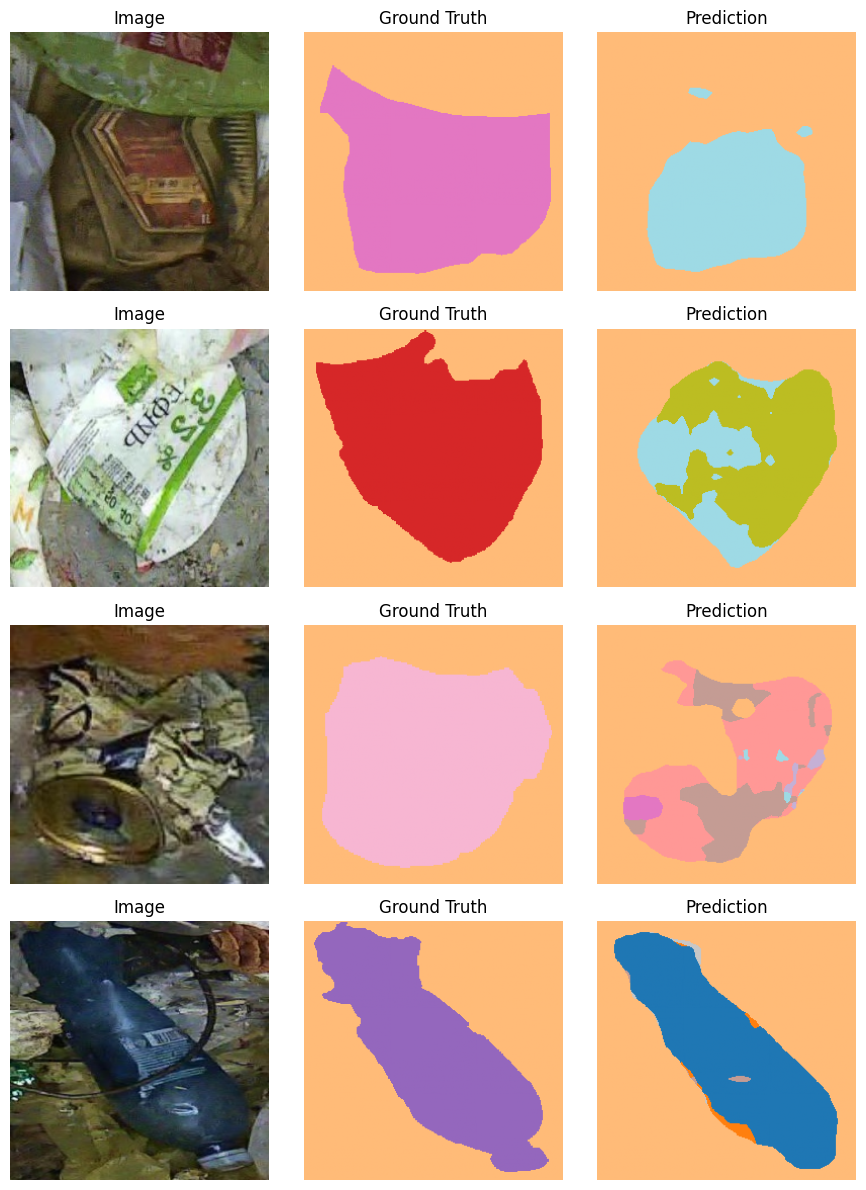

In [15]:
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)["out"].argmax(dim=1).cpu()

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

num_show = min(4, images.size(0))
fig, axes = plt.subplots(num_show, 3, figsize=(9, 3 * num_show))

for i in range(num_show):
    img_display = (images[i].cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(masks[i], cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(preds[i], cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("segmentation_predictions.png", dpi=150)
plt.show()

In [16]:
import json

with open("segmentation_history.json", "w") as f:
    json.dump(history, f, indent=2)

torch.save(model.state_dict(), "deeplabv3_warps_final.pth")

files.download("segmentation_history.json")
files.download("deeplabv3_warps_final.pth")
files.download("segmentation_predictions.png")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>